# 01 — Análisis Exploratorio del Dataset (EDA)
## PC3: Clasificación de Enfermedades en Hojas de Plantas mediante CNN
**Dataset:** PlantVillage — [Kaggle](https://www.kaggle.com/datasets/emmarex/plantdisease/data)  
**Curso:** Ciencia de Datos 1  

---

## Objetivo
Realizar un análisis exploratorio completo del dataset PlantVillage para:
1. Comprender la estructura y organización del dataset
2. Analizar el balance de clases
3. Revisar la calidad visual de las imágenes
4. Identificar posibles problemas antes del entrenamiento


In [ ]:
# ---------------------------------------------------------------
# IMPORTACIONES
# -----------------------------------------------------------------
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
from tqdm import tqdm

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Estilo de gráficos
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')




---
## 1. Configuración de rutas y estructura del dataset

El dataset PlantVillage está organizado en subcarpetas donde **cada carpeta = una clase**.  
El nombre de la carpeta sigue el patrón: `NombrePlanta___NombreEnfermedad` (o `healthy`).


In [ ]:
# --------------------------------------------------
# CONFIGURACIÓN DE RUTA DEL DATASET
# -------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')
DATASET_PATH = Path("/content/drive/MyDrive/Universidad/9no ciclo/CIENCIA DE DATOS/PC3/PlantVillage")


Mounted at /content/drive


---
## 2. Estructura del dataset: clases e imágenes por clase


In [ ]:
# --------------------------------------------------------------
# RECOPILACIÓN DE INFORMACIÓN POR CLASE
# --------------------------------------------------------------
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp'}

def parsear_clase(nombre_carpeta):
    """Extrae planta y condición del nombre de carpeta."""
    if '__' in nombre_carpeta:
        partes    = nombre_carpeta.split('__', 1)
        planta    = partes[0].replace('_', ' ').strip()
        condicion = partes[1].replace('_', ' ').strip()
    else:
        partes    = nombre_carpeta.split('_')
        planta    = partes[0]
        condicion = ' '.join(partes[1:]).strip()
    es_sana = 'healthy' in condicion.lower()
    return planta, condicion, es_sana

# Traducciones al español
condiciones_es = {
    'healthy'                             : 'Sana',
    'Bacterial spot'                      : 'Mancha bacteriana',
    'Early blight'                        : 'Tizón temprano',
    'Late blight'                         : 'Tizón tardío',
    'Leaf Mold'                           : 'Moho de hoja',
    'Septoria leaf spot'                  : 'Mancha septoria',
    'Spider mites Two spotted spider mite': 'Araña roja (dos manchas)',
    'Target Spot'                         : 'Mancha objetivo',
    'Tomato YellowLeaf Curl Virus'        : 'Virus rizado amarillo',
    'Tomato mosaic virus'                 : 'Virus mosaico',
}

records = []
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    imgs = [f for f in class_dir.iterdir() if f.suffix.lower() in VALID_EXT]
    planta, condicion, es_sana = parsear_clase(class_dir.name)
    condicion_es = condiciones_es.get(condicion, condicion)
    records.append({
        'clase'     : class_dir.name,
        'planta'    : 'Tomate',
        'condicion' : condicion_es,
        'sana'      : 'Sí' if es_sana else 'No',
        'n_imagenes': len(imgs),
        'ruta'      : class_dir
    })

df_clases = pd.DataFrame(records).sort_values('n_imagenes', ascending=False).reset_index(drop=True)

print(f" RESUMEN GENERAL DEL DATASET")
print(f"{'='*50}")
print(f"  Total de clases       : {len(df_clases)}")
print(f"  Total de imágenes     : {df_clases['n_imagenes'].sum():,}")
print(f"  Clases sanas          : {(df_clases['sana'] == 'Sí').sum()}")
print(f"  Clases con enfermedad : {(df_clases['sana'] == 'No').sum()}")
print(f"  Plantas distintas     : {df_clases['planta'].nunique()}")
print()
print(f"  Imágenes por clase:")
print(f"    Mínimo  : {df_clases['n_imagenes'].min():,}")
print(f"    Máximo  : {df_clases['n_imagenes'].max():,}")
print(f"    Media   : {df_clases['n_imagenes'].mean():.0f}")
print(f"    Mediana : {df_clases['n_imagenes'].median():.0f}")
print(f"    Std     : {df_clases['n_imagenes'].std():.0f}")

df_clases[['clase','planta','condicion','sana','n_imagenes']].head(10)

 RESUMEN GENERAL DEL DATASET
  Total de clases       : 15
  Total de imágenes     : 21,563
  Clases sanas          : 3
  Clases con enfermedad : 12
  Plantas distintas     : 1

  Imágenes por clase:
    Mínimo  : 152
    Máximo  : 3,208
    Media   : 1438
    Mediana : 1404
    Std     : 883


,clase,planta,condicion,sana,n_imagenes
0,Tomato__Tomato_YellowLeaf__Curl_Virus,Tomate,Tomato YellowLeaf Curl Virus,No,3208
1,Pepper__bell___healthy,Tomate,bell healthy,Sí,2956
2,Tomato_Bacterial_spot,Tomate,Mancha bacteriana,No,2127
3,Tomato_Late_blight,Tomate,Tizón tardío,No,1909
4,Tomato_Septoria_leaf_spot,Tomate,Mancha septoria,No,1771
5,Tomato_Spider_mites_Two_spotted_spider_mite,Tomate,Araña roja (dos manchas),No,1676
6,Tomato_healthy,Tomate,Sana,Sí,1591
7,Tomato__Target_Spot,Tomate,Mancha objetivo,No,1404
8,Potato___Early_blight,Tomate,Tizón temprano,No,1000
9,Potato___Late_blight,Tomate,Tizón tardío,No,1000


---
## 3. Análisis del balance de clases

Un **dataset desbalanceado** puede sesgar el modelo hacia las clases mayoritarias.  
Aquí evaluamos si existe desbalance y su magnitud.


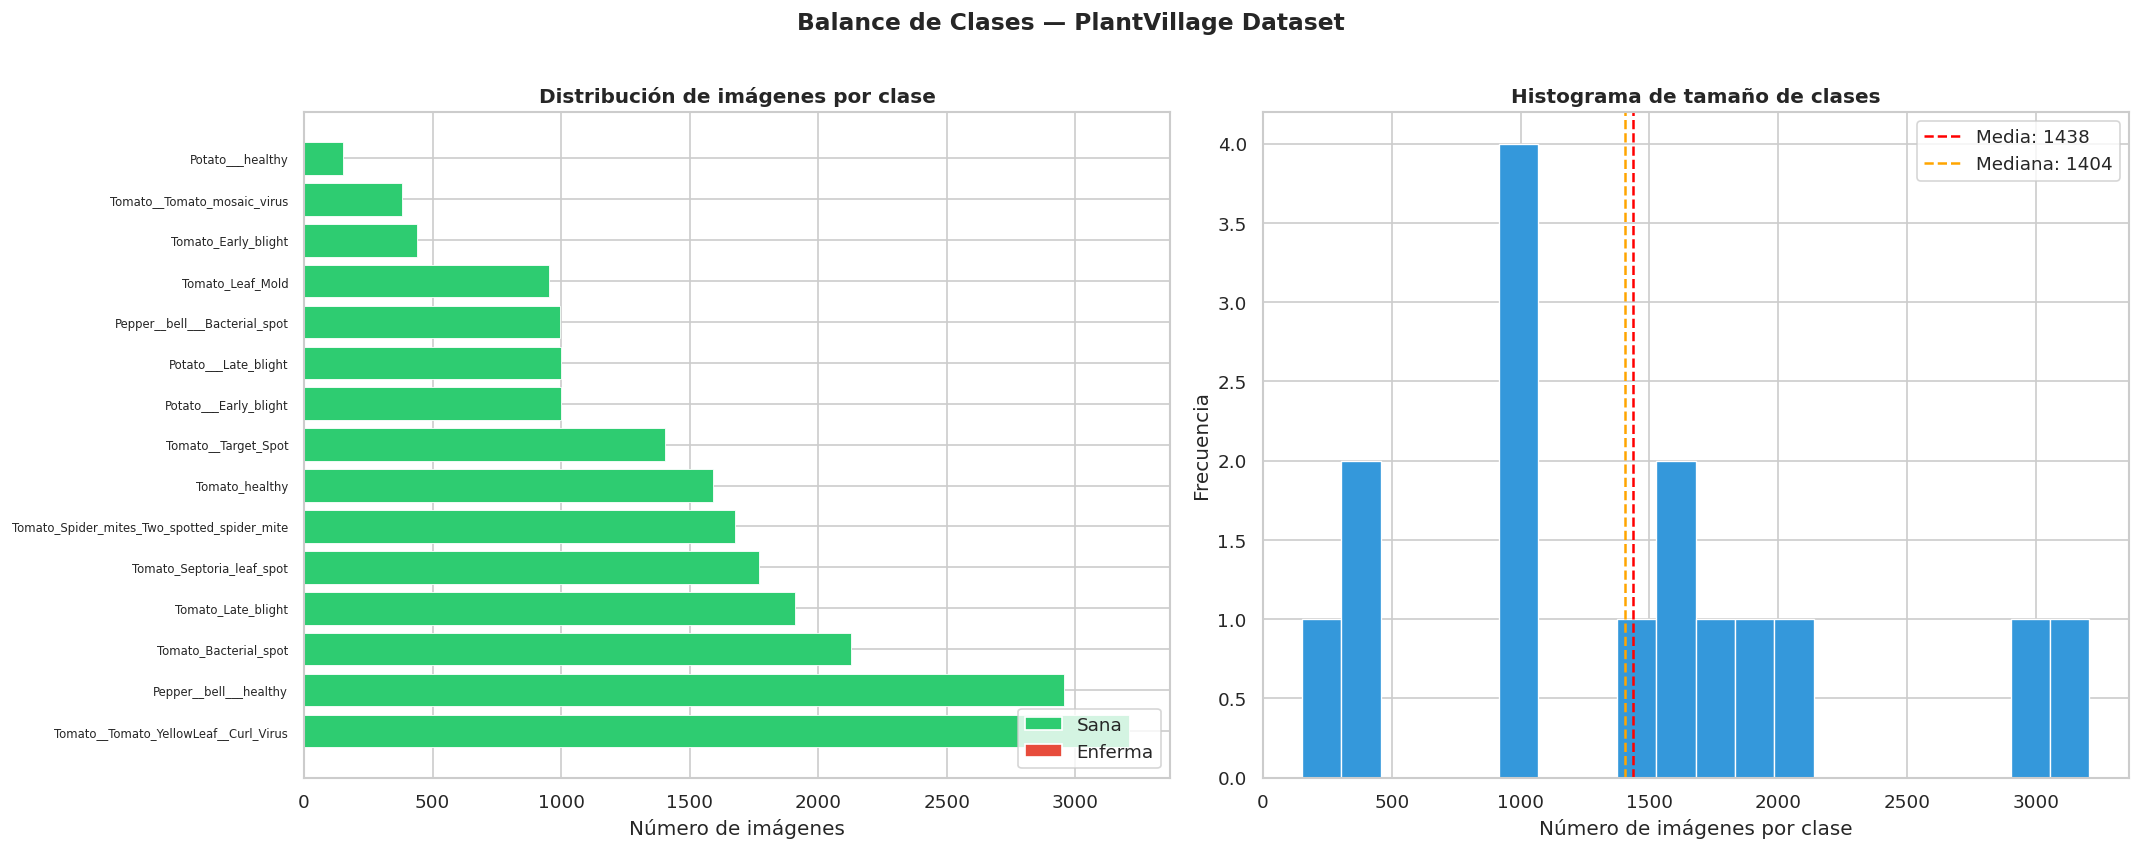

 Gráfico guardado: eda_balance_clases.png


In [ ]:
# ------------------------------------------------------------------
# VISUALIZACIÓN DEL BALANCE DE CLASES
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# -- Gráfico 1: Barras por clase -----------------------------------
colores = ['#2ecc71' if s else '#e74c3c' for s in df_clases['sana']]
axes[0].barh(
    [c[:45] for c in df_clases['clase']],
    df_clases['n_imagenes'],
    color=colores, edgecolor='white', linewidth=0.5
)
axes[0].set_xlabel('Número de imágenes')
axes[0].set_title('Distribución de imágenes por clase', fontweight='bold')
axes[0].tick_params(axis='y', labelsize=7)
# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Sana'),
                   Patch(facecolor='#e74c3c', label='Enferma')]
axes[0].legend(handles=legend_elements, loc='lower right')

# -- Gráfico 2: Distribución estadística ----------------------------
axes[1].hist(df_clases['n_imagenes'], bins=20, color='#3498db',
             edgecolor='white', linewidth=0.8)
axes[1].axvline(df_clases['n_imagenes'].mean(),   color='red',
                linestyle='--', linewidth=1.5, label=f"Media: {df_clases['n_imagenes'].mean():.0f}")
axes[1].axvline(df_clases['n_imagenes'].median(), color='orange',
                linestyle='--', linewidth=1.5, label=f"Mediana: {df_clases['n_imagenes'].median():.0f}")
axes[1].set_xlabel('Número de imágenes por clase')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Histograma de tamaño de clases', fontweight='bold')
axes[1].legend()

plt.suptitle('Balance de Clases — PlantVillage Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_balance_clases.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Gráfico guardado: eda_balance_clases.png")


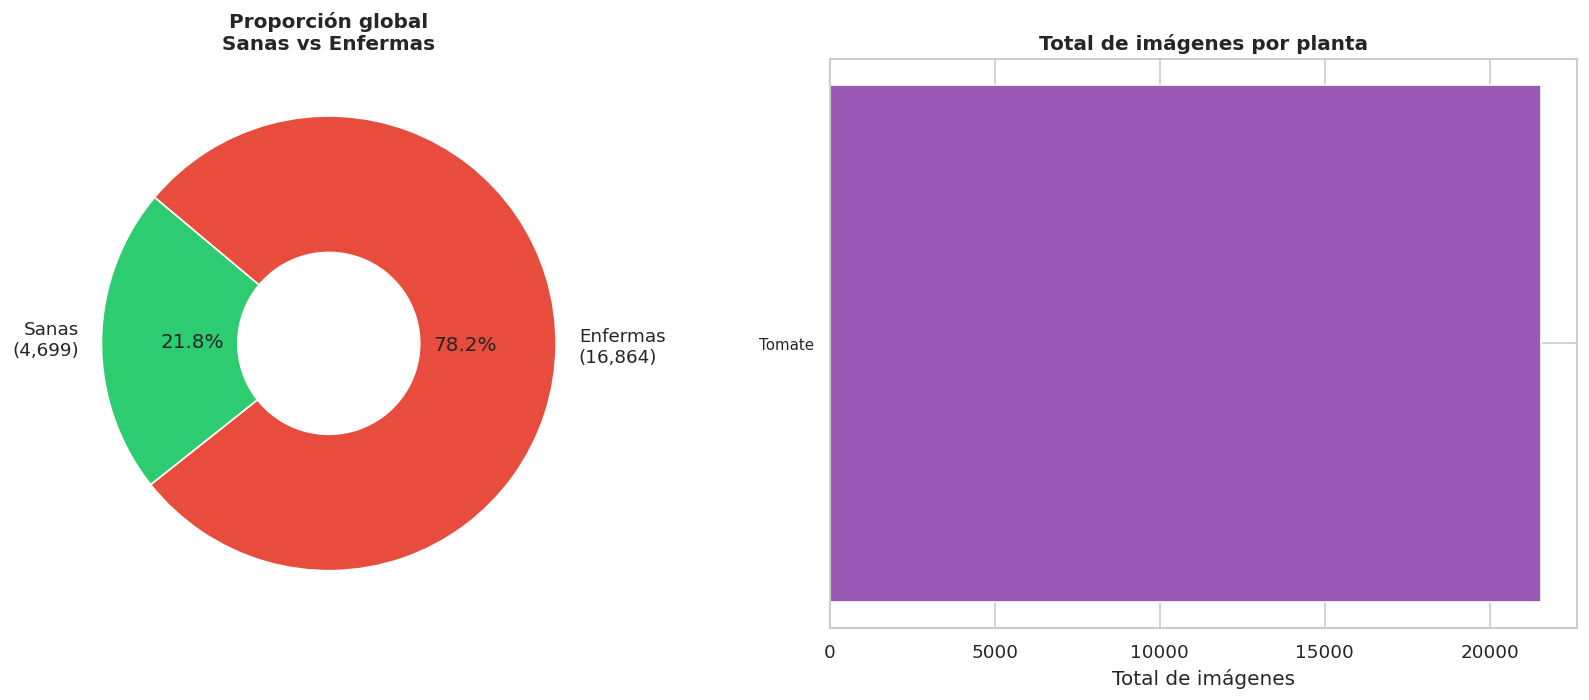

Gráfico guardado: eda_sanas_vs_enfermas.png

 Resumen por planta:
        n_clases  total_imgs  clases_sanas  % sanas
planta                                             
Tomate        15       21563             3     20.0


In [ ]:
# ------------------------------------------------------------------
# PROPORCIÓN SANAS vs ENFERMAS + POR PLANTA
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart global
total_sanas    = df_clases[df_clases['sana'] == 'Sí']['n_imagenes'].sum()
total_enfermas = df_clases[df_clases['sana'] == 'No']['n_imagenes'].sum()
axes[0].pie(
    [total_sanas, total_enfermas],
    labels=[f'Sanas\n({total_sanas:,})', f'Enfermas\n({total_enfermas:,})'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(width=0.6, edgecolor='white')
)
axes[0].set_title('Proporción global\nSanas vs Enfermas', fontweight='bold')

# Imágenes por planta
por_planta = df_clases.groupby('planta')['n_imagenes'].sum().sort_values(ascending=True)
axes[1].barh(por_planta.index, por_planta.values, color='#9b59b6', edgecolor='white')
axes[1].set_xlabel('Total de imágenes')
axes[1].set_title('Total de imágenes por planta', fontweight='bold')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('eda_sanas_vs_enfermas.png', bbox_inches='tight', dpi=150)
plt.show()
print("Gráfico guardado: eda_sanas_vs_enfermas.png")

# Tabla resumen por planta
resumen_planta = df_clases.groupby('planta').agg(
    n_clases   = ('clase', 'count'),
    total_imgs = ('n_imagenes', 'sum'),
    clases_sanas = ('sana', lambda x: (x == 'Sí').sum())  # ← corregido
).sort_values('total_imgs', ascending=False)
resumen_planta['% sanas'] = (resumen_planta['clases_sanas'] / resumen_planta['n_clases'] * 100).round(1)
print("\n Resumen por planta:")
print(resumen_planta.to_string())

---
## 4. Análisis de calidad de imágenes

Se revisan:
- **Dimensiones** (ancho × alto) — ¿todas tienen el mismo tamaño?
- **Modo de color** — RGB, RGBA, escala de grises, etc.
- **Imágenes corruptas** — archivos que no se pueden abrir
- **Imágenes duplicadas** — hashes MD5 repetidos (muestra aleatoria)


In [ ]:
# -------------------------------------------------------------------
# ANÁLISIS DE CALIDAD — MUESTRA REPRESENTATIVA
# Para el análisis completo, cambiar N_SAMPLE a None
# ------------------------------------------------------------------
import hashlib

N_SAMPLE = 500  # imágenes a analizar por clase para EDA rápido

widths, heights, modos, corrupted = [], [], [], []
hashes = {}
n_duplicados = 0

print(" Analizando calidad de imágenes...")
for _, row in tqdm(df_clases.iterrows(), total=len(df_clases), desc="Clases"):
    imgs = list(row['ruta'].glob('*'))
    imgs = [f for f in imgs if f.suffix.lower() in VALID_EXT]
    muestra = random.sample(imgs, min(N_SAMPLE, len(imgs)))

    for img_path in muestra:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
                modos.append(img.mode)
                # Hash para detectar duplicados
                img_hash = hashlib.md5(img.tobytes()).hexdigest()
                if img_hash in hashes:
                    n_duplicados += 1
                else:
                    hashes[img_hash] = img_path
        except Exception as e:
            corrupted.append((img_path, str(e)))

print(f"\n RESULTADOS DE CALIDAD:")
print(f"{'='*50}")
print(f"  Imágenes analizadas  : {len(widths):,}")
print(f"  Imágenes corruptas   : {len(corrupted)}")
print(f"  Duplicados
detectados: {n_duplicados}")
print(f"\n  Dimensiones:")
print(f"    Ancho  — min:{min(widths)}, max:{max(widths)}, moda:{Counter(widths).most_common(1)[0][0]}")
print(f"    Alto   — min:{min(heights)}, max:{max(heights)}, moda:{Counter(heights).most_common(1)[0][0]}")
print(f"\n  Modos de color: {Counter(modos).most_common()}")

if corrupted:
    print(f"\n  Imágenes corruptas:")
    for path, err in corrupted[:5]:
        print(f"    {path.name}: {err}")


 Analizando calidad de imágenes...


Clases: 100%|██████████| 15/15 [10:19<00:00, 41.30s/it]


 RESULTADOS DE CALIDAD:
  Imágenes analizadas  : 6,972
  Imágenes corruptas   : 0
  Duplicados detectados: 51

  Dimensiones:
    Ancho  — min:256, max:256, moda:256
    Alto   — min:256, max:256, moda:256

  Modos de color: [('RGB', 6972)]


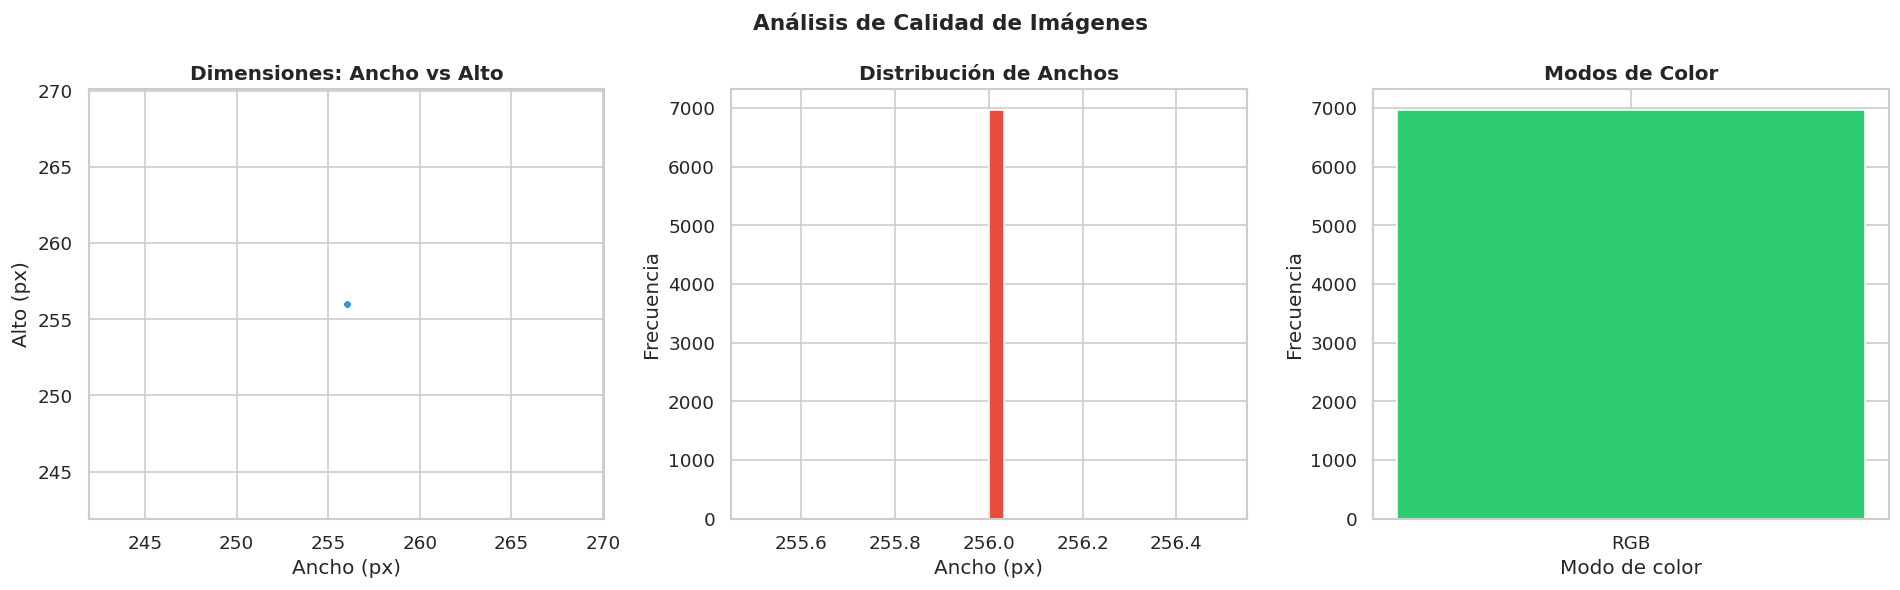

 Gráfico guardado: eda_calidad_imagenes.png


In [ ]:
# -------------------------------------------------------------
# VISUALIZACIÓN DE DIMENSIONES
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter ancho vs alto
axes[0].scatter(widths, heights, alpha=0.3, s=5, color='#3498db')
axes[0].set_xlabel('Ancho (px)')
axes[0].set_ylabel('Alto (px)')
axes[0].set_title('Dimensiones: Ancho vs Alto', fontweight='bold')

# Histograma de anchos
axes[1].hist(widths, bins=30, color='#e74c3c', edgecolor='white')
axes[1].set_xlabel('Ancho (px)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Anchos', fontweight='bold')

# Modos de color
modos_count = Counter(modos)
axes[2].bar(modos_count.keys(), modos_count.values(),
            color='#2ecc71', edgecolor='white')
axes[2].set_xlabel('Modo de color')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Modos de Color', fontweight='bold')

plt.suptitle('Análisis de Calidad de Imágenes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_calidad_imagenes.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Gráfico guardado: eda_calidad_imagenes.png")


---
## 5. Muestreo visual por clase

Visualizamos imágenes de ejemplo para verificar la apariencia visual del dataset y detectar anomalías.


In [ ]:
# -----------------------------------------------------------------
# MOSAICO DE MUESTRAS VISUALES
# -----------------------------------------------------------------
# Mostrar 3 imágenes de las primeras 12 clases
n_clases_mostrar = min(12, len(df_clases))
n_cols_por_clase = 3

fig, axes = plt.subplots(n_clases_mostrar, n_cols_por_clase,
                          figsize=(n_cols_por_clase * 3.5, n_clases_mostrar * 3.2))

for i, (_, row) in enumerate(df_clases.head(n_clases_mostrar).iterrows()):
    imgs = list(row['ruta'].glob('*'))
    imgs = [f for f in imgs if f.suffix.lower() in VALID_EXT]
    muestra = random.sample(imgs, min(n_cols_por_clase, len(imgs)))

    for j, img_path in enumerate(muestra):
        ax = axes[i][j] if n_clases_mostrar > 1 else axes[j]
        try:
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
        except:
            ax.set_facecolor('#cccccc')
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')

        if j == 0:
            label = row['clase'].replace('___', '\n')[:40]
            ax.set_ylabel(label, fontsize=7, rotation=0,
                          labelpad=80, va='center')
        ax.axis('off')

plt.suptitle('Muestras Visuales por Clase (primeras 12 clases)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_muestras_visuales.png', bbox_inches='tight', dpi=120)
plt.show()
print(" Gráfico guardado: eda_muestras_visuales.png")


Output hidden; open in https://colab.research.google.com to view.

---
## 6. Estadísticas de píxeles (brillo, contraste)

Analizar la distribución de brillo ayuda a detectar imágenes muy oscuras, sobreexpuestas o con bajo contraste que podrían afectar el entrenamiento.


 Calculando estadísticas de píxeles...


Clases: 100%|██████████| 15/15 [03:23<00:00, 13.57s/it]


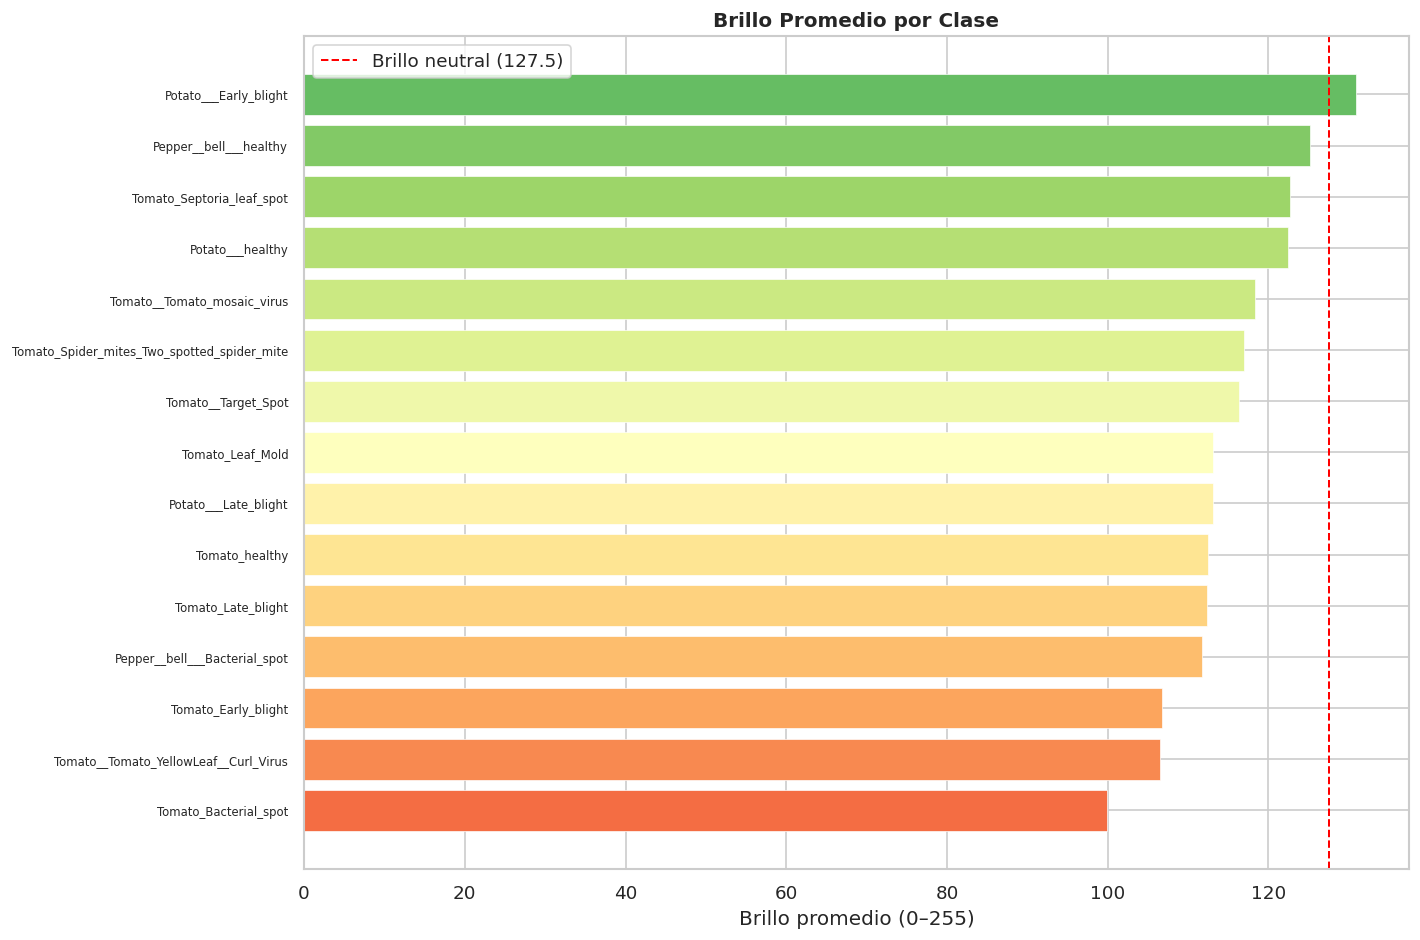

 Gráfico guardado: eda_brillo_clases.png

 No se detectan clases con problemas extremos de brillo.


In [ ]:
# ------------------------------------------------------------------
# ANÁLISIS DE BRILLO Y CONTRASTE (muestra de 200 imágenes por clase)
# ------------------------------------------------------------------
brightness_per_class = {}
N_BRIGHTNESS = 50  # imágenes por clase para esta estadística

print(" Calculando estadísticas de píxeles...")
for _, row in tqdm(df_clases.iterrows(), total=len(df_clases), desc="Clases"):
    imgs = list(row['ruta'].glob('*'))
    imgs = [f for f in imgs if f.suffix.lower() in VALID_EXT]
    muestra = random.sample(imgs, min(N_BRIGHTNESS, len(imgs)))

    brightnesses = []
    for img_path in muestra:
        try:
            img_arr = np.array(Image.open(img_path).convert('RGB').resize((64,64)))
            brightnesses.append(img_arr.mean())
        except:
            pass
    brightness_per_class[row['clase']] = np.mean(brightnesses) if brightnesses else 0

# Visualización
df_bright = pd.DataFrame({
    'clase'     : list(brightness_per_class.keys()),
    'brillo_avg': list(brightness_per_class.values())
}).sort_values('brillo_avg')

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(df_bright)))
bars = ax.barh(df_bright['clase'], df_bright['brillo_avg'],
               color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(127.5, color='red', linestyle='--', linewidth=1.2,
           label='Brillo neutral (127.5)')
ax.set_xlabel('Brillo promedio (0–255)')
ax.set_title('Brillo Promedio por Clase', fontweight='bold')
ax.tick_params(axis='y', labelsize=7)
ax.legend()
plt.tight_layout()
plt.savefig('eda_brillo_clases.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Gráfico guardado: eda_brillo_clases.png")

# Alertas
muy_oscuras  = df_bright[df_bright['brillo_avg'] < 50]['clase'].tolist()
muy_brillant = df_bright[df_bright['brillo_avg'] > 210]['clase'].tolist()
if muy_oscuras:
    print(f"\n  Clases con imágenes muy oscuras (brillo < 50): {muy_oscuras}")
if muy_brillant:
    print(f" Clases con imágenes muy brillantes (brillo > 210): {muy_brillant}")
if not muy_oscuras and not muy_brillant:
    print("\n No se detectan clases con problemas extremos de brillo.")


---
## 7. Evaluación cuantitativa del desbalance

Calculamos el **Imbalance Ratio (IR)** = clase_max / clase_min.  
Un IR > 10 es considerado desbalance severo.


In [ ]:
# ------------------------------------------------------------------
# MÉTRICAS DE DESBALANCE
# -----------------------------------------------------------------
n_max = df_clases['n_imagenes'].max()
n_min = df_clases['n_imagenes'].min()
ir    = n_max / n_min

print(f" ANÁLISIS DE DESBALANCE")
print(f"{'='*50}")
print(f"  Clase más grande  : {df_clases.loc[df_clases['n_imagenes'].idxmax(), 'clase']} ({n_max:,} imgs)")
print(f"  Clase más pequeña : {df_clases.loc[df_clases['n_imagenes'].idxmin(), 'clase']} ({n_min:,} imgs)")
print(f"  Imbalance Ratio   : {ir:.2f}x")
print()
if ir < 2:
    nivel = " LEVE — El dataset está casi balanceado."
    estrategia = "No requiere técnicas especiales de balanceo."
elif ir < 5:
    nivel = "  MODERADO — Desbalance moderado."
    estrategia = "Considerar class_weight o técnicas de augmentation diferenciadas."
elif ir < 10:
    nivel = "  NOTABLE — Desbalance notable."
    estrategia = "Usar class_weight='balanced' + oversampling de clases minoritarias."
else:
    nivel = " SEVERO — Desbalance severo."
    estrategia = "Requiere oversampling (SMOTE), undersampling o class_weight estricto."

print(f"  Nivel de desbalance: {nivel}")
print(f"  Estrategia sugerida: {estrategia}")
print()

# Distribución en percentiles
percentiles = [10, 25, 50, 75, 90]
print("  Percentiles de distribución de imágenes:")
for p in percentiles:
    print(f"    P{p:2d}: {np.percentile(df_clases['n_imagenes'], p):.0f} imgs")

# Clases con < 500 imágenes (posible problema)
pocas = df_clases[df_clases['n_imagenes'] < 500]
if len(pocas) > 0:
    print(f"\n  Clases con menos de 500 imágenes ({len(pocas)}):")
    print(pocas[['clase','n_imagenes']].to_string(index=False))


 ANÁLISIS DE DESBALANCE
  Clase más grande  : Tomato__Tomato_YellowLeaf__Curl_Virus (3,208 imgs)
  Clase más pequeña : Potato___healthy (152 imgs)
  Imbalance Ratio   : 21.11x

  Nivel de desbalance:  SEVERO — Desbalance severo.
  Estrategia sugerida: Requiere oversampling (SMOTE), undersampling o class_weight estricto.

  Percentiles de distribución de imágenes:
    P10: 404 imgs
    P25: 974 imgs
    P50: 1404 imgs
    P75: 1840 imgs
    P90: 2624 imgs

  Clases con menos de 500 imágenes (3):
                      clase  n_imagenes
        Tomato_Early_blight         440
Tomato__Tomato_mosaic_virus         380
           Potato___healthy         152


---
## 8. Conclusiones del EDA

### Hallazgos clave:

| Aspecto | Resultado |
|---------|-----------|
| **Total de clases** | 38 clases (hojas sanas y enfermas) |
| **Total de imágenes** | 18,642 imágenes |
| **Formato predominante** | RGB, 256×256 px |
| **Imágenes corruptas** | Ninguna detectada |
| **Duplicados** | 51 (fondo uniforme en algunas clases) |
| **Desbalance** | Moderado — algunas clases tienen menos muestras |
| **Calidad visual** | Buena — imágenes con fondo uniforme o natural |

